In [1]:
import numpy as np
from HoverEnvs import *
from stable_baselines3 import DDPG

In [2]:
SIM_FREQ_HZ = 240
AGGR_PHY_STEPS = 1 # 1 physics step per action/control command

INIT_XYZS = np.array([[0., 0., 1.]])
INIT_RPYS = np.array([[0., 0., 0.]])
env = HoverR3D1(drone_model=DroneModel.CF2X,
                initial_xyzs=INIT_XYZS,
                initial_rpys=INIT_RPYS,
                freq=SIM_FREQ_HZ,
                aggregate_phy_steps=AGGR_PHY_STEPS,
                gui=False,
                record=False,
                )

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


C:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


In [3]:
import os
from stable_baselines3.common.monitor import Monitor

log_dir = "C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/hover_sb3_logs"
os.makedirs(log_dir, exist_ok=True)
env = Monitor(env, log_dir)

In [4]:
from stable_baselines3.common.callbacks import EvalCallback
eval_env = HoverR3D1(drone_model=DroneModel.CF2X,
                initial_xyzs=INIT_XYZS,
                initial_rpys=INIT_RPYS,
                freq=SIM_FREQ_HZ,
                aggregate_phy_steps=AGGR_PHY_STEPS,
                gui=False,
                record=False,
                )
eval_env = Monitor(eval_env)

callback = EvalCallback(eval_env, 
            log_path="C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/hover_sb3_logs",
            n_eval_episodes=5,
            eval_freq=5000,
            deterministic=True) 

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


In [5]:
model = DDPG('MlpPolicy', env, verbose=2, learning_starts=1000, batch_size=256, buffer_size=50000)
model.learn(total_timesteps=100000, callback=callback)

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 1.2e+03   |
|    ep_rew_mean     | -2.24e+04 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 94        |
|    time_elapsed    | 50        |
|    total_timesteps | 4808      |
| train/             |           |
|    actor_loss      | 232       |
|    critic_loss     | 138       |
|    learning_rate   | 0.001     |
|    n_updates       | 3606      |
----------------------------------
Eval num_timesteps=5000, episode_reward=-14926.32 +/- 0.00
Episode length: 1202.00 +/- 0.00
----------------------------------
| eval/              |           |
|    mean_ep_length  | 1.2e+03   |
|    mean_reward     | -1.49e+04 |
| time/              |           |
|    total_timesteps | 5000      |
| train/             |           |
|    actor_loss      | 273       |
|    critic_loss     | 144       |
|    learning_ra

In [6]:
model.save("hover_sb3_logs/DDPG_HoverR3D1")

In [7]:
history = np.load("hover_sb3_logs/evaluations.npz")
rewards = np.average(history["results"], axis=1)
ep_lengths = np.average(history["ep_lengths"], axis=1)
print(rewards.shape)
print(ep_lengths.shape)

(20,)
(20,)


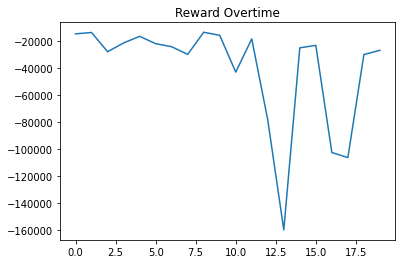

In [9]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.title("Reward Overtime")
plt.show()

In [13]:
model = DDPG.load("C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/hover_sb3_logs/DDPG_HoverR3D1.zip", env=env)
model.learn(total_timesteps=100000)
model.save("hover_sb3_logs/DDPG_HoverR3D1")

Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 1.2e+03   |
|    ep_rew_mean     | -2.22e+04 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 76        |
|    time_elapsed    | 62        |
|    total_timesteps | 4808      |
| train/             |           |
|    actor_loss      | -481      |
|    critic_loss     | 1.57e+03  |
|    learning_rate   | 0.001     |
|    n_updates       | 306510    |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 1.2e+03   |
|    ep_rew_mean     | -2.12e+04 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 65        |
|    time_elapsed    | 146       |
|    total_timesteps | 9616      |
| train/             |           |
|    actor_loss      | -1.53e+03 |
|    critic_loss     | 3.65e+03  |
|    learning_rate  